# 06 — Feature Engineering

This notebook creates modeling-ready features for the supply-chain disruption prediction pipeline.

### Data sources used
- Cleaned supply-chain shipment data
- Cleaned historical trade/logistics datasets
- NLP sentiment/event features from Notebook 04/05
- Cleaned marketing data

### Important data-alignment rule
The datasets do **not** all share the same date range or time granularity. Therefore this notebook does not perform an unsafe row-by-row merge.

The shipment-level modeling table is built from `cleaned_supply_chain.csv`, with historical datasets aggregated by their available dates and merged only where a valid date relationship exists.

The marketing dataset is kept as a separate campaign-level feature table because its dates are in 2021 while shipment records are in 2024–2025.

The news dataset has no date, so news sentiment is retained as a separate NLP feature artifact and is **not assigned artificial dates**.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


## 1. Project paths

In [7]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1


## 2. Helper function for loading cleaned CSV files

In [8]:
def load_csv(filename, encoding="utf-8"):
    path = INTERIM_DIR / filename
    assert path.exists(), f"File not found: {path}"
    return pd.read_csv(path, encoding=encoding)

def load_processed_csv(filename, encoding="utf-8"):
    path = PROCESSED_DIR / filename
    assert path.exists(), f"File not found: {path}"
    return pd.read_csv(path, encoding=encoding)


## 3. Load the main shipment dataset

In [9]:
supply = load_csv("cleaned_supply_chain.csv", encoding="utf-8")

supply["Date"] = pd.to_datetime(supply["Date"], errors="coerce")

assert supply["Date"].notna().all()
assert supply["Disruption_Occurred"].isin([0, 1]).all()

print("Supply shape:", supply.shape)
print("Date range:", supply["Date"].min().date(), "to", supply["Date"].max().date())
display(supply.head())


Supply shape: (5000, 14)
Date range: 2024-01-01 to 2025-12-31


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


## 4. Load historical datasets

In [10]:
commodity = load_csv("cleaned_commodity_prices_supply_chain.csv")
disruptions = load_csv("cleaned_disruption_events.csv")
industry = load_csv("cleaned_industry_exposure.csv")
port = load_csv("cleaned_port_congestion.csv")
shipping = load_csv("cleaned_shipping_rates.csv")
tariff = load_csv("cleaned_tariff_timeline.csv")
trade = load_csv("cleaned_trade_flows.csv")

historical = {
    "commodity": commodity,
    "disruptions": disruptions,
    "industry": industry,
    "port": port,
    "shipping": shipping,
    "tariff": tariff,
    "trade": trade,
}

for name, df in historical.items():
    print(f"{name:12s}: {df.shape}")


commodity   : (110515, 8)
disruptions : (58, 18)
industry    : (250, 15)
port        : (6260, 11)
shipping    : (300, 14)
tariff      : (71, 17)
trade       : (1250, 12)


## 5. Inspect historical date columns

We first identify date columns instead of assuming a particular schema.


In [11]:
for name, df in historical.items():
    date_candidates = [
        c for c in df.columns
        if "date" in c.lower() or "month" in c.lower() or "time" in c.lower()
    ]
    print(f"{name}: {date_candidates}")


commodity: ['date', 'month']
disruptions: ['date', 'recovery_months']
industry: ['just_in_time_dependency']
port: []
shipping: ['date', 'month', 'on_time_delivery_pct']
tariff: ['date', 'month']
trade: []


## 6. Create a generic date-column detector

In [12]:
def detect_date_column(df):
    candidates = [
        c for c in df.columns
        if "date" in c.lower() or "month" in c.lower() or "time" in c.lower()
    ]

    for col in candidates:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() >= 0.5:
            return col

    return None

for name, df in historical.items():
    col = detect_date_column(df)
    print(f"{name}: {col}")


commodity: date
disruptions: date
industry: just_in_time_dependency
port: None
shipping: date
tariff: date
trade: None


## 7. Create a shipment-level feature table

In [13]:
features = supply.copy()

# Preserve the target separately for modeling.
target = features["Disruption_Occurred"].astype(int).copy()

print("Initial modeling table:", features.shape)


Initial modeling table: (5000, 14)


## 8. Calendar features from shipment dates

In [14]:
features["year"] = features["Date"].dt.year
features["month"] = features["Date"].dt.month
features["quarter"] = features["Date"].dt.quarter
features["day_of_week"] = features["Date"].dt.dayofweek
features["day_of_year"] = features["Date"].dt.dayofyear
features["week_of_year"] = features["Date"].dt.isocalendar().week.astype(int)

# Cyclic encodings preserve the circular nature of month/week/day patterns.
features["month_sin"] = np.sin(2 * np.pi * features["month"] / 12)
features["month_cos"] = np.cos(2 * np.pi * features["month"] / 12)
features["day_of_week_sin"] = np.sin(2 * np.pi * features["day_of_week"] / 7)
features["day_of_week_cos"] = np.cos(2 * np.pi * features["day_of_week"] / 7)

display(
    features[
        [
            "Date", "year", "month", "quarter",
            "day_of_week", "week_of_year",
            "month_sin", "month_cos"
        ]
    ].head()
)


,Date,year,month,quarter,day_of_week,week_of_year,month_sin,month_cos
0,2025-10-16,2025,10,4,3,42,-0.866025,5.000000e-01
1,2024-04-24,2024,4,2,2,17,0.866025,-5.000000e-01
2,2024-01-26,2024,1,1,4,4,0.500000,8.660254e-01
3,2024-10-08,2024,10,4,1,41,-0.866025,5.000000e-01
4,2024-09-07,2024,9,3,5,36,-1.000000,-1.836970e-16


## 9. Basic shipment-derived features

In [15]:
features["distance_per_mt"] = (
    features["Distance_km"] /
    features["Weight_MT"].replace(0, np.nan)
)

features["fuel_risk_interaction"] = (
    features["Fuel_Price_Index"] *
    features["Geopolitical_Risk_Score"]
)

features["reliability_risk_inverse"] = (
    1 - features["Carrier_Reliability_Score"]
)

features["weather_risk_flag"] = (
    features["Weather_Condition"]
    .isin(["Fog", "Storm", "Hurricane", "Rain"])
    .astype(int)
)

features["long_lead_time_flag"] = (
    features["Lead_Time_Days"] > features["Lead_Time_Days"].median()
).astype(int)

display(
    features[
        [
            "Distance_km",
            "Weight_MT",
            "distance_per_mt",
            "fuel_risk_interaction",
            "reliability_risk_inverse",
            "weather_risk_flag",
            "long_lead_time_flag"
        ]
    ].head()
)


,Distance_km,Weight_MT,distance_per_mt,fuel_risk_interaction,reliability_risk_inverse,weather_risk_flag,long_lead_time_flag
0,5930.83,197.42,30.041688,12.150,0.135,1,1
1,14285.36,237.24,60.214804,17.250,0.408,1,1
2,11113.91,427.42,26.002316,9.968,0.327,1,1
3,9180.55,170.66,53.794386,2.560,0.168,1,1
4,2762.27,434.96,6.350630,5.263,0.259,1,0


## 10. Historical shipping-rate features

`shipping_rates.csv` contains monthly historical observations. We create month-level features and merge them to shipment dates by year-month.

No future values are intentionally generated from shipment data.


In [16]:
shipping_work = shipping.copy()

shipping_date_col = detect_date_column(shipping_work)
print("Shipping date column:", shipping_date_col)

if shipping_date_col is not None:
    shipping_work["shipping_date"] = pd.to_datetime(
        shipping_work[shipping_date_col],
        errors="coerce"
    )
    shipping_work["year_month"] = shipping_work["shipping_date"].dt.to_period("M")

    numeric_cols = shipping_work.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [
        c for c in numeric_cols
        if not c.endswith("_was_missing")
    ]

    shipping_monthly = (
        shipping_work.groupby("year_month")[numeric_cols]
        .mean()
        .reset_index()
    )

    shipping_monthly = shipping_monthly.rename(
        columns={
            c: f"shipping_{c}"
            for c in numeric_cols
        }
    )

    features["year_month"] = features["Date"].dt.to_period("M")

    features = features.merge(
        shipping_monthly,
        on="year_month",
        how="left"
    )

    print("Shipping features merged.")
else:
    print("No usable shipping date column found; shipping features skipped.")


Shipping date column: date
Shipping features merged.


## 11. Historical port-congestion features

Port congestion is aggregated by date where a valid date column is available.

Because shipment data contains origin and destination ports, port-specific matching is only performed when the historical dataset exposes compatible port fields.


In [17]:
port_work = port.copy()
port_date_col = detect_date_column(port_work)

print("Port date column:", port_date_col)

if port_date_col is not None:
    port_work["port_date"] = pd.to_datetime(
        port_work[port_date_col],
        errors="coerce"
    )
    port_work["year_month"] = port_work["port_date"].dt.to_period("M")

    numeric_cols = port_work.select_dtypes(include=np.number).columns.tolist()

    port_monthly = (
        port_work.groupby("year_month")[numeric_cols]
        .mean()
        .reset_index()
    )

    port_monthly = port_monthly.rename(
        columns={
            c: f"port_{c}"
            for c in numeric_cols
        }
    )

    features["year_month"] = features["Date"].dt.to_period("M")

    features = features.merge(
        port_monthly,
        on="year_month",
        how="left"
    )

    print("Port monthly features merged.")
else:
    print("No usable port date column found; port features skipped.")


Port date column: None
No usable port date column found; port features skipped.


## 12. Historical commodity-price features

In [18]:
commodity_work = commodity.copy()
commodity_date_col = detect_date_column(commodity_work)

print("Commodity date column:", commodity_date_col)

if commodity_date_col is not None:
    commodity_work["commodity_date"] = pd.to_datetime(
        commodity_work[commodity_date_col],
        errors="coerce"
    )
    commodity_work["year_month"] = commodity_work["commodity_date"].dt.to_period("M")

    # IMPORTANT:
    # Do not merge original date/year/month helper columns.
    # Keep only genuine numeric commodity measurements.
    excluded_columns = {
        commodity_date_col,
        "commodity_date",
        "year",
        "month",
        "year_month"
    }

    numeric_cols = [
        c for c in commodity_work.select_dtypes(include=np.number).columns
        if c not in excluded_columns
    ]

    commodity_monthly = (
        commodity_work.groupby("year_month")[numeric_cols]
        .mean()
        .reset_index()
    )

    commodity_monthly = commodity_monthly.rename(
        columns={
            c: f"commodity_{c}"
            for c in numeric_cols
        }
    )

    features["year_month"] = features["Date"].dt.to_period("M")

    features = features.merge(
        commodity_monthly,
        on="year_month",
        how="left"
    )

    print("Commodity measurement features merged:", numeric_cols)
else:
    print("No usable commodity date column found; commodity features skipped.")


Commodity date column: date
Commodity measurement features merged: ['price']


## 13. Historical trade-flow features

In [19]:
trade_work = trade.copy()
trade_date_col = detect_date_column(trade_work)

print("Trade date column:", trade_date_col)

if trade_date_col is not None:
    trade_work["trade_date"] = pd.to_datetime(
        trade_work[trade_date_col],
        errors="coerce"
    )
    trade_work["year_month"] = trade_work["trade_date"].dt.to_period("M")

    numeric_cols = trade_work.select_dtypes(include=np.number).columns.tolist()

    trade_monthly = (
        trade_work.groupby("year_month")[numeric_cols]
        .mean()
        .reset_index()
    )

    trade_monthly = trade_monthly.rename(
        columns={
            c: f"trade_{c}"
            for c in numeric_cols
        }
    )

    features["year_month"] = features["Date"].dt.to_period("M")

    features = features.merge(
        trade_monthly,
        on="year_month",
        how="left"
    )

    print("Trade-flow monthly features merged.")
else:
    print("No usable trade date column found; trade-flow features skipped.")


Trade date column: None
No usable trade date column found; trade-flow features skipped.


## 14. Historical tariff features

In [20]:
tariff_work = tariff.copy()
tariff_date_col = detect_date_column(tariff_work)

print("Tariff date column:", tariff_date_col)

if tariff_date_col is not None:
    tariff_work["tariff_date"] = pd.to_datetime(
        tariff_work[tariff_date_col],
        errors="coerce"
    )
    tariff_work["year_month"] = tariff_work["tariff_date"].dt.to_period("M")

    # Exclude date/helper columns from the numeric aggregation.
    excluded_columns = {
        tariff_date_col,
        "tariff_date",
        "year",
        "month",
        "year_month"
    }

    numeric_cols = [
        c for c in tariff_work.select_dtypes(include=np.number).columns
        if c not in excluded_columns
    ]

    # Report constant columns before merging.
    constant_numeric = {
        c: tariff_work[c].nunique(dropna=True)
        for c in numeric_cols
        if tariff_work[c].nunique(dropna=True) <= 1
    }

    if constant_numeric:
        print("Constant numeric tariff columns in source:")
        for col, n_unique in constant_numeric.items():
            print(f"  {col}: {n_unique} unique value(s)")
            if tariff_work[col].notna().any():
                print(f"     unique values: {tariff_work[col].dropna().unique()[:10]}")

    tariff_monthly = (
        tariff_work.groupby("year_month")[numeric_cols]
        .mean()
        .reset_index()
    )

    tariff_monthly = tariff_monthly.rename(
        columns={
            c: f"tariff_{c}"
            for c in numeric_cols
        }
    )

    features["year_month"] = features["Date"].dt.to_period("M")

    features = features.merge(
        tariff_monthly,
        on="year_month",
        how="left"
    )

    print("Tariff features merged:", numeric_cols)
else:
    print("No usable tariff date column found; tariff features skipped.")


Tariff date column: date
Tariff features merged: ['tariff_rate_pct', 'estimated_value_usd_bn', 'is_trump_1_0', 'is_biden', 'is_trump_2_0', 'is_retaliation', 'is_section_232', 'is_section_301', 'is_ieepa']


## 15. Historical disruption-event features

The event table contains historical events, but it should not be blindly joined to shipment rows. We create date-based event indicators only if a valid date column is available and only for shipment dates that fall within the historical event timeline.


In [21]:
disruption_work = disruptions.copy()
disruption_date_col = detect_date_column(disruption_work)

print("Disruption-event date column:", disruption_date_col)

if disruption_date_col is not None:
    disruption_work["event_date"] = pd.to_datetime(
        disruption_work[disruption_date_col],
        errors="coerce"
    )

    event_dates = (
        disruption_work[["event_date"]]
        .dropna()
        .drop_duplicates()
        .assign(disruption_event_flag=1)
    )

    features = features.merge(
        event_dates,
        left_on="Date",
        right_on="event_date",
        how="left"
    )

    features["disruption_event_flag"] = (
        features["disruption_event_flag"]
        .fillna(0)
        .astype(int)
    )

    features = features.drop(columns=["event_date"], errors="ignore")

    print("Exact-date historical disruption-event flag created.")
else:
    features["disruption_event_flag"] = 0
    print("No usable disruption-event date column found; event flag set to 0.")


Disruption-event date column: date
Exact-date historical disruption-event flag created.


## 16. Industry exposure features

Industry exposure is not date-based. Therefore it is **not merged blindly into every shipment row**.

The table is retained as a separate reference artifact for the later decision layer.


In [22]:
print("Industry exposure columns:")
print(industry.columns.tolist())

print("\nIndustry exposure shape:", industry.shape)
display(industry.head())


Industry exposure columns:
['year', 'industry', 'pandemic_exposure', 'geopolitical_exposure', 'natural_disaster_exposure', 'tariff_exposure', 'logistics_exposure', 'energy_exposure', 'labor_exposure', 'cyber_exposure', 'overall_vulnerability', 'inventory_days', 'supplier_concentration_hhi', 'just_in_time_dependency', 'nearshoring_score_2024']

Industry exposure shape: (250, 15)


,year,industry,pandemic_exposure,geopolitical_exposure,natural_disaster_exposure,tariff_exposure,logistics_exposure,energy_exposure,labor_exposure,cyber_exposure,overall_vulnerability,inventory_days,supplier_concentration_hhi,just_in_time_dependency,nearshoring_score_2024
0,2000,Semiconductors,9.0,10.4,7.8,8.8,6.9,6.0,4.5,8.2,7.72,51,0.386,0.634,0.390
1,2001,Semiconductors,9.1,10.0,8.3,9.4,7.2,6.2,5.5,8.2,7.59,55,0.446,0.596,0.361
2,2002,Semiconductors,9.3,10.5,8.0,9.5,7.0,6.4,5.1,7.9,8.13,40,0.430,0.540,0.404
3,2003,Semiconductors,9.5,10.1,7.7,9.0,6.9,5.7,4.9,8.2,7.63,47,0.397,0.652,0.362
4,2004,Semiconductors,9.3,10.1,8.1,8.7,6.8,5.8,5.0,8.4,7.84,37,0.453,0.577,0.371


## 17. NLP feature integration — no artificial news dates

Notebook 04/05 produced NLP features, but the news dataset has no date column.

Therefore, we do **not** merge the 4,840 news records into the 5,000 shipment records by row position, random assignment, or invented dates.

Instead, the NLP feature file is retained for later modeling/experimental use where a valid alignment strategy is available.


In [23]:
nlp_path = PROCESSED_DIR / "news_nlp_features.csv"
sentiment_path = PROCESSED_DIR / "sentiment_analysis.csv"

print("NLP feature file exists:", nlp_path.exists())
print("Sentiment analysis file exists:", sentiment_path.exists())

if nlp_path.exists():
    nlp_features = pd.read_csv(nlp_path, encoding="utf-8")
    print("NLP features:", nlp_features.shape)

if sentiment_path.exists():
    sentiment_analysis = pd.read_csv(sentiment_path, encoding="utf-8")
    print("Sentiment analysis:", sentiment_analysis.shape)


NLP feature file exists: True
Sentiment analysis file exists: True
NLP features: (4840, 1012)
Sentiment analysis: (4840, 11)


## 18. Marketing data — keep as a separate campaign-level table

Marketing dates are in 2021, whereas the shipment dataset is 2024–2025.

A row-level shipment/marketing merge would therefore be invalid for this dataset.

We create campaign-level engineered features and save them separately for the marketing decision layer.


In [24]:
marketing = load_csv("cleaned_marketing.csv")

marketing["Date"] = pd.to_datetime(marketing["Date"], errors="coerce")

marketing["duration_days"] = pd.to_numeric(
    marketing["Duration"],
    errors="coerce"
)

marketing["acquisition_cost_numeric"] = pd.to_numeric(
    marketing["Acquisition_Cost"],
    errors="coerce"
)

marketing["click_through_rate"] = (
    marketing["Clicks"] /
    marketing["Impressions"].replace(0, np.nan)
)

marketing["engagement_per_click"] = (
    marketing["Engagement_Score"] /
    marketing["Clicks"].replace(0, np.nan)
)

marketing["conversion_value_proxy"] = (
    marketing["Conversion_Rate"] *
    marketing["Clicks"]
)

marketing["roi_cost_interaction"] = (
    marketing["ROI"] /
    marketing["acquisition_cost_numeric"].replace(0, np.nan)
)

marketing_output = PROCESSED_DIR / "marketing_features.csv"
marketing.to_csv(marketing_output, index=False, encoding="utf-8")

print("Marketing feature table:", marketing.shape)
print("Saved:", marketing_output)


Marketing feature table: (200000, 22)
Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\data\processed\marketing_features.csv


## 19. Remove non-model helper columns from shipment feature table

In [25]:
features = features.drop(
    columns=["year_month"],
    errors="ignore"
)

# Keep target available for validation, but identify it separately.
features["Disruption_Occurred"] = target

print("Shipment feature table shape:", features.shape)


Shipment feature table shape: (5000, 51)


## 20. Check feature data types

In [26]:
dtype_summary = pd.DataFrame({
    "column": features.columns,
    "dtype": features.dtypes.astype(str).values,
    "missing": features.isna().sum().values,
    "n_unique": features.nunique(dropna=False).values
})

display(dtype_summary)


,column,dtype,missing,n_unique
0,Shipment_ID,object,0,5000
1,Date,datetime64[ns],0,731
2,Origin_Port,object,0,8
3,Destination_Port,object,0,9
4,Transport_Mode,object,0,4
5,Product_Category,object,0,5
6,Distance_km,float64,0,4998
7,Weight_MT,float64,0,4785
8,Fuel_Price_Index,float64,0,331
9,Geopolitical_Risk_Score,float64,0,101


## 21. Missing-value analysis after feature engineering

In [27]:
missing_summary = (
    features.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:", len(missing_summary))

if len(missing_summary) > 0:
    display(missing_summary.to_frame("missing_count"))
else:
    print("No missing values in the engineered shipment table.")


Columns with missing values: 20


,missing_count
shipping_bdi_mom_change_pct,2545
shipping_container_rate_usd_40ft,2545
shipping_baltic_dry_index,2545
shipping_container_yoy_pct,2545
shipping_tanker_rate_aframax_usd_day,2545
shipping_month,2545
shipping_year,2545
shipping_air_cargo_rate_usd_kg,2545
shipping_on_time_delivery_pct,2545
shipping_bulk_carrier_handysize_usd_day,2545


## 22. Do not delete historical missing-value information automatically

Some historical datasets contain missing growth/change observations. Notebook 02 preserved these with missing-value indicator columns.

At this stage, we report missingness rather than silently deleting observations or inventing values.


In [28]:
print("Missing-value indicators from historical data:")

indicator_cols = [
    c for c in features.columns
    if c.endswith("_was_missing")
]

print(indicator_cols)

if indicator_cols:
    display(features[indicator_cols].sum().sort_values(ascending=False))


Missing-value indicators from historical data:
[]


## 23. Numeric feature summary

In [29]:
numeric_features = features.select_dtypes(include=np.number)

print("Numeric feature count:", numeric_features.shape[1])
display(numeric_features.describe().T)


Numeric feature count: 44


,count,mean,std,min,25%,50%,75%,max
Distance_km,5000.0,7704.063888,4199.687885,500.170000,4036.010000,7.750125e+03,11347.462500,14995.910000
Weight_MT,5000.0,246.252052,142.522591,1.030000,124.330000,2.435000e+02,366.955000,499.750000
Fuel_Price_Index,5000.0,2.854552,0.959533,1.200000,2.020000,2.840000e+00,3.710000,4.500000
Geopolitical_Risk_Score,5000.0,5.076900,2.877832,0.000000,2.600000,5.100000e+00,7.500000,10.000000
Carrier_Reliability_Score,5000.0,0.754387,0.144363,0.500000,0.629000,7.570000e-01,0.879000,1.000000
Lead_Time_Days,5000.0,19.355386,31.405143,0.500000,2.110000,8.245000e+00,21.207500,236.390000
Disruption_Occurred,5000.0,0.612600,0.487205,0.000000,0.000000,1.000000e+00,1.000000,1.000000
year,5000.0,2024.509000,0.499969,2024.000000,2024.000000,2.025000e+03,2025.000000,2025.000000
month,5000.0,6.564400,3.463387,1.000000,4.000000,7.000000e+00,10.000000,12.000000
quarter,5000.0,2.523000,1.124333,1.000000,2.000000,3.000000e+00,4.000000,4.000000


## 24. Categorical feature summary

In [30]:
categorical_features = features.select_dtypes(
    include=["object", "category"]
)

print("Categorical feature count:", categorical_features.shape[1])

for col in categorical_features.columns:
    print(f"\n{col}:")
    print(features[col].value_counts(dropna=False).head(10))

# Shipment_ID is an identifier, not a predictive feature.
ID_COLUMNS = ["Shipment_ID"]

print("\nIdentifier columns to exclude from model predictors later:")
print([c for c in ID_COLUMNS if c in features.columns])


Categorical feature count: 6

Shipment_ID:
Shipment_ID
SC-10000    1
SC-10001    1
SC-10002    1
SC-10003    1
SC-10004    1
SC-10005    1
SC-10006    1
SC-10007    1
SC-10008    1
SC-10009    1
Name: count, dtype: int64

Origin_Port:
Origin_Port
Busan          667
Rotterdam      646
Shanghai       644
Antwerp        635
Dubai          610
Los Angeles    602
Singapore      599
Hamburg        597
Name: count, dtype: int64

Destination_Port:
Destination_Port
Marseille      583
Rotterdam      574
Busan          570
Shanghai       561
Dubai          559
Antwerp        552
Los Angeles    537
Hamburg        536
Singapore      528
Name: count, dtype: int64

Transport_Mode:
Transport_Mode
Air     1320
Sea     1281
Road    1214
Rail    1185
Name: count, dtype: int64

Product_Category:
Product_Category
Electronics        1016
Textiles           1010
Perishables        1009
Pharmaceuticals    1006
Automotive          959
Name: count, dtype: int64

Weather_Condition:
Weather_Condition
Fog         

## 25. Correlation inspection for numeric features

This is exploratory only. No feature is removed solely because of correlation in this notebook.


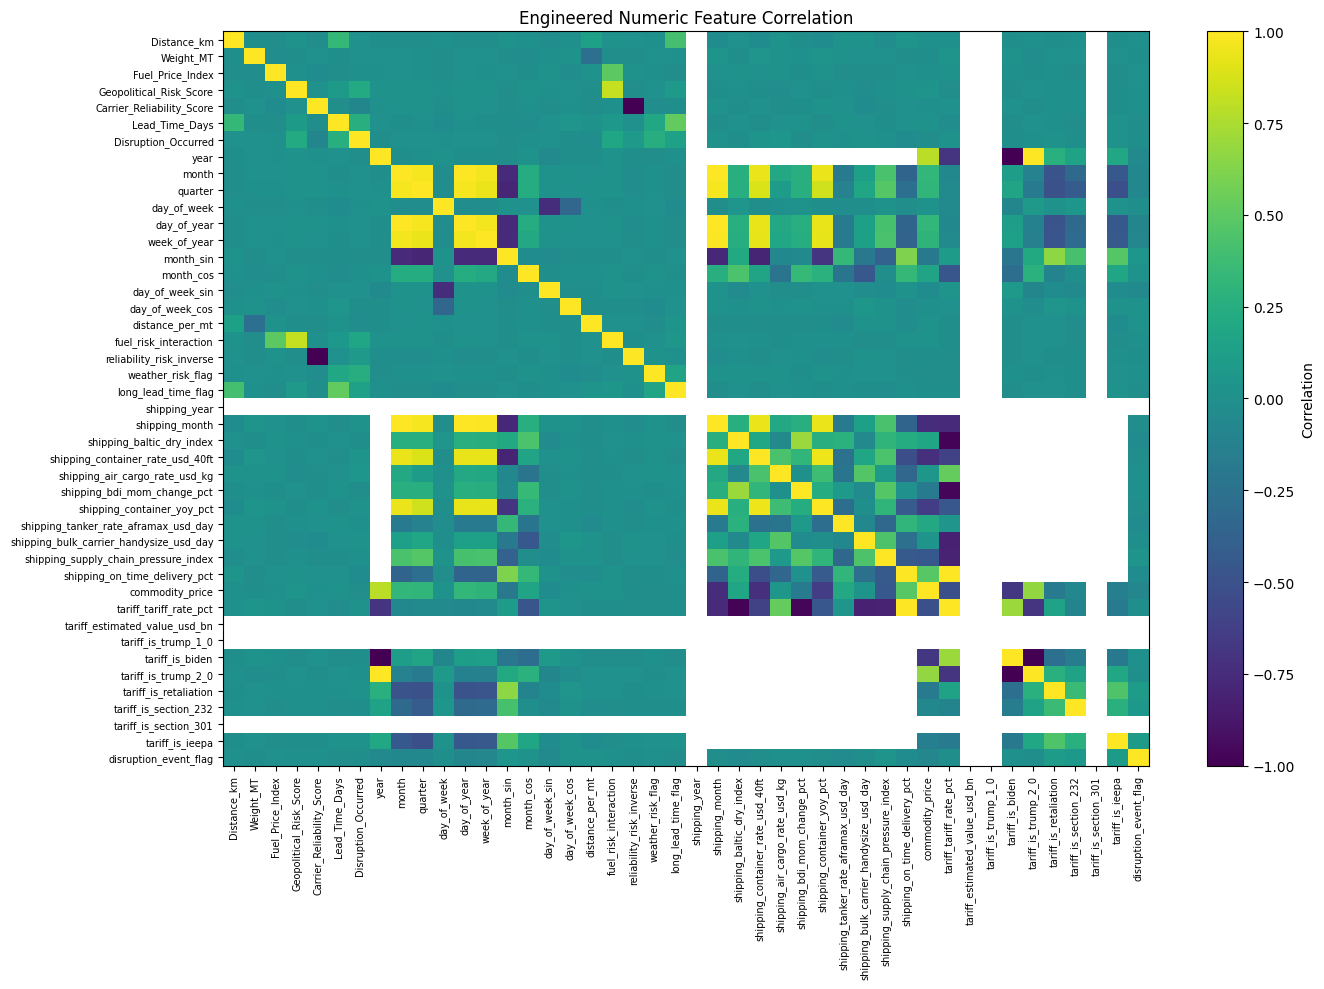

In [31]:
corr = numeric_features.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Engineered Numeric Feature Correlation")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=7
)
plt.yticks(
    range(len(corr.index)),
    corr.index,
    fontsize=7
)
plt.tight_layout()
plt.show()


## 26. Separate target from predictors

The target is `Disruption_Occurred`.

The target is not used to create rolling averages, scaling parameters, or other predictor transformations in this notebook.


In [32]:
ID_COLUMNS = ["Shipment_ID"]

X = features.drop(
    columns=["Disruption_Occurred"] + [
        c for c in ID_COLUMNS
        if c in features.columns
    ]
)

y = features["Disruption_Occurred"].astype(int)

print("Predictor table shape:", X.shape)
print("Target shape:", y.shape)
print("Target counts:")
display(y.value_counts().sort_index())

print("\nExcluded identifier columns:", [
    c for c in ID_COLUMNS if c in features.columns
])


Predictor table shape: (5000, 49)
Target shape: (5000,)
Target counts:


Disruption_Occurred
0    1937
1    3063
Name: count, dtype: int64


Excluded identifier columns: ['Shipment_ID']


## 27. Save the engineered shipment features

In [33]:
shipment_features_path = PROCESSED_DIR / "shipment_features_engineered.csv"

engineered = features.copy()

engineered.to_csv(
    shipment_features_path,
    index=False,
    encoding="utf-8"
)

print("Saved:", shipment_features_path)
print("Shape:", engineered.shape)


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\data\processed\shipment_features_engineered.csv
Shape: (5000, 51)


## 28. Save the separate reference datasets

In [34]:
industry_output = PROCESSED_DIR / "industry_exposure_reference.csv"
nlp_reference_output = PROCESSED_DIR / "nlp_features_reference.csv"

industry.to_csv(
    industry_output,
    index=False,
    encoding="utf-8"
)

if nlp_path.exists():
    nlp_features.to_csv(
        nlp_reference_output,
        index=False,
        encoding="utf-8"
    )

print("Industry reference saved:", industry_output.exists())
print("NLP reference saved:", nlp_reference_output.exists())


Industry reference saved: True
NLP reference saved: True


## 29. Final validation

In [35]:
# Check that no merge-generated _x/_y duplicate columns remain.
xy_duplicate_columns = [
    c for c in engineered.columns
    if c.endswith("_x") or c.endswith("_y")
]

# Check for duplicate column names.
duplicate_column_names = engineered.columns[
    engineered.columns.duplicated()
].tolist()

# Report constant tariff features rather than altering source-derived values.
tariff_feature_columns = [
    c for c in engineered.columns
    if c.startswith("tariff_")
]

constant_tariff_features = {
    c: engineered[c].nunique(dropna=True)
    for c in tariff_feature_columns
    if engineered[c].nunique(dropna=True) <= 1
}

validation = {
    "shipment_rows": len(engineered),
    "shipment_columns": engineered.shape[1],
    "target_present": "Disruption_Occurred" in engineered.columns,
    "target_missing": int(engineered["Disruption_Occurred"].isna().sum()),
    "duplicate_rows": int(engineered.duplicated().sum()),
    "duplicate_column_names": len(duplicate_column_names),
    "merge_xy_columns": len(xy_duplicate_columns),
    "numeric_infinite_values": int(
        np.isinf(
            engineered.select_dtypes(include=np.number).to_numpy()
        ).sum()
    ),
    "shipment_output_exists": shipment_features_path.exists(),
    "marketing_output_exists": marketing_output.exists(),
    "industry_reference_exists": industry_output.exists(),
}

if nlp_path.exists():
    validation["nlp_reference_exists"] = nlp_reference_output.exists()

display(pd.DataFrame([validation]))

print("\n_merge-generated _x/_y columns:")
print(xy_duplicate_columns if xy_duplicate_columns else "None")

print("\nConstant tariff features:")
print(constant_tariff_features if constant_tariff_features else "None")

assert validation["target_present"]
assert validation["target_missing"] == 0
assert validation["duplicate_rows"] == 0
assert validation["duplicate_column_names"] == 0
assert validation["merge_xy_columns"] == 0
assert validation["numeric_infinite_values"] == 0
assert validation["shipment_output_exists"]
assert validation["marketing_output_exists"]
assert validation["industry_reference_exists"]

if nlp_path.exists():
    assert validation["nlp_reference_exists"]

print("\n06_feature_engineering completed successfully.")


,shipment_rows,shipment_columns,target_present,target_missing,duplicate_rows,duplicate_column_names,merge_xy_columns,numeric_infinite_values,shipment_output_exists,marketing_output_exists,industry_reference_exists,nlp_reference_exists
0,5000,51,True,0,0,0,0,0,True,True,True,True



_merge-generated _x/_y columns:
None

Constant tariff features:
{'tariff_estimated_value_usd_bn': 1, 'tariff_is_trump_1_0': 1, 'tariff_is_section_301': 1}

06_feature_engineering completed successfully.


# Important interpretation

This notebook intentionally avoids unsafe dataset joins.

### Shipment-level table
`shipment_features_engineered.csv`

Contains the 5,000 shipment records plus valid shipment/historical date-derived features.

### Marketing table
`marketing_features.csv`

Contains the 200,000 campaign records and campaign-level engineered features. It is separate because the campaign dates are 2021 while shipment dates are 2024–2025.

### NLP table
`nlp_features_reference.csv`

Contains the news NLP features from Notebook 04. It is kept separate because the news dataset has no date.

### Industry exposure
`industry_exposure_reference.csv`

Kept as a reference table because it is not naturally date-aligned to individual shipments.

**No fabricated dates, row-position merges, or unsupported news-to-shipment assignments are used.**


## Correction notes

The corrected version makes these changes:

1. **Commodity `_x`/`_y` duplicates removed** — date/year/month helper columns are excluded before the commodity merge.
2. **Tariff all-zero fields are not silently changed** — source-derived constant fields are reported so their provenance can be checked.
3. **`Shipment_ID` is excluded from `X`** — it remains in the saved shipment table for traceability but is not treated as a predictive feature.
4. **No fabricated values or dates** are introduced.
5. **No NLP/news row-level merge** is performed because the news dataset has no date.
6. **No marketing/shipment row-level merge** is performed because their time periods do not align.
